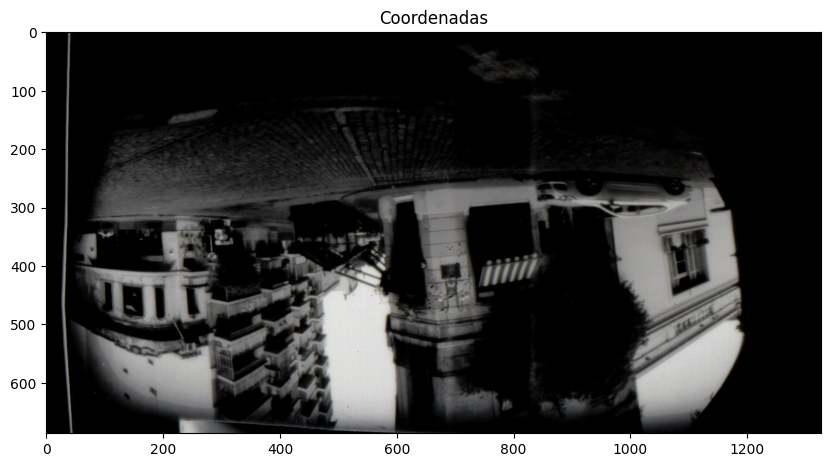

Forma: (687, 1327, 3)


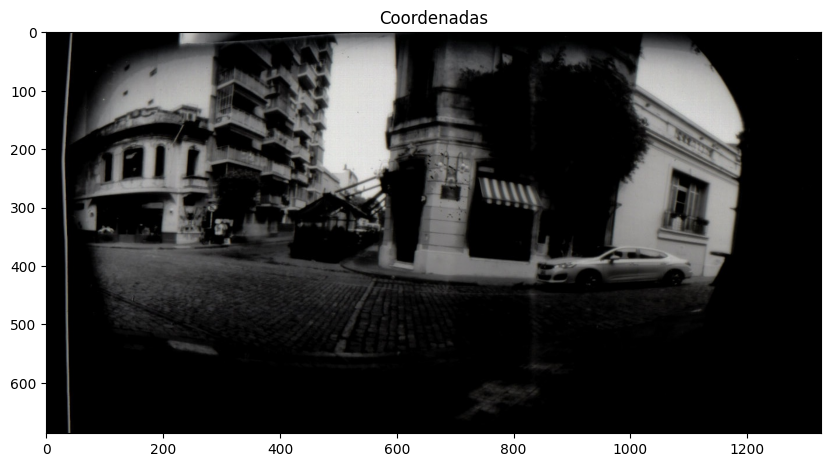

Forma: (687, 1327, 3)


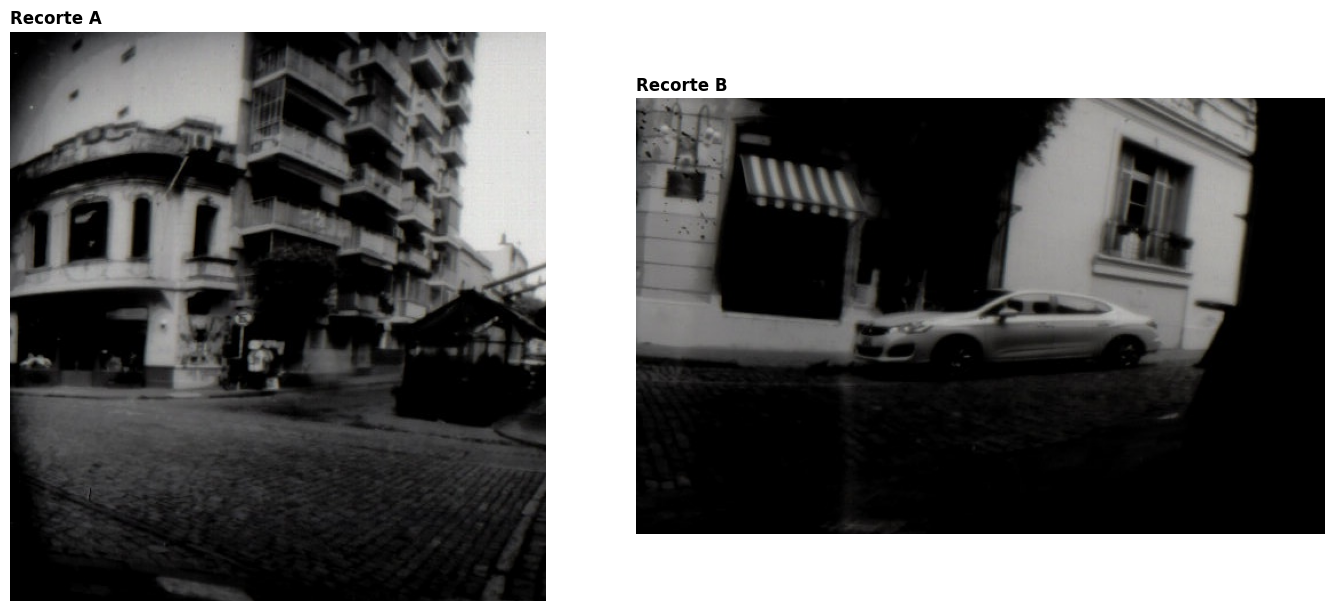

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Ubicación
carpeta_imagenes = Path("../imagenes/originales")
carpeta_salidas = Path("../imagenes/procesadas")
carpeta_salidas.mkdir(parents=True, exist_ok=True)

# Carga
img_reencuadre_bgr = cv2.imread(str(carpeta_imagenes / "reencuadre.jpg"))
if img_reencuadre_bgr is None:
    raise FileNotFoundError(f"No se encontró la imagen en: {(carpeta_imagenes / 'reencuadre.jpg').resolve()}")
img_reencuadre_rgb = cv2.cvtColor(img_reencuadre_bgr, cv2.COLOR_BGR2RGB)

# Roto, invierto y negativizo
img_girada = cv2.rotate(img_reencuadre_rgb, cv2.ROTATE_90_CLOCKWISE)
img_invertida = cv2.flip(img_girada, -1)
img_negativo = cv2.bitwise_not(img_invertida)

# Coordenadas para definir recorte
plt.figure(figsize=(10, 8))
plt.imshow(img_negativo)
plt.title("Coordenadas")
plt.axis("on")
plt.show()
print("Forma:", img_negativo.shape)

# vuelvo a girar porque quedó al revés
img_girada = cv2.rotate(img_reencuadre_rgb, cv2.ROTATE_90_CLOCKWISE)
img_invertida = cv2.flip(img_girada, -1)
img_negativo = cv2.bitwise_not(img_invertida)
img_derecha = cv2.flip(img_negativo, 0) 

plt.figure(figsize=(10, 8))
plt.imshow(img_derecha, cmap="gray")
plt.title("Coordenadas")
plt.axis("on")
plt.show()
print("Forma:", img_derecha.shape)

# Defino recortes
recorte_a = img_derecha[50:550, 80:550]
recorte_b = img_derecha[200:580, 650:1250]

figura, ejes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
ejes[0].imshow(recorte_a, cmap="gray")
ejes[0].set_title("Recorte A", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(recorte_b, cmap="gray")
ejes[1].set_title("Recorte B", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()